# **Data Collection**


In [ ]:
# CELL 1: Setup Earth Engine and create project folder

!pip install earthengine-api geemap --quiet

import ee
import geemap
from google.colab import drive

print("Earth Engine API version:", ee.__version__)

# Mount Google Drive
drive.mount('/content/drive')

# Authenticate Earth Engine
ee.Authenticate()

# Initialize Earth Engine project
ee.Initialize(project='mini-project-gaya-dist')
print("Earth Engine initialized successfully")

# Define main output folder (all exports will be saved here)
OUTPUT_FOLDER = "mini_project_1"
print("Output folder set to:", OUTPUT_FOLDER)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.0 MB/s eta 0:00:00
Earth Engine API version: 1.5.24
Mounted at /content/drive
Earth Engine initialized successfully
Output folder set to: mini_project_1


In [ ]:
# CELL 2: Define cloud masks and Gaya district AOI

import os

# Sentinel-2 cloud mask
def maskS2clouds(image):
    qa = image.select('QA60')
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(
           qa.bitwiseAnd(cirrusBitMask).eq(0))
    return image.updateMask(mask).divide(10000)

# Landsat-8 cloud + shadow mask
def maskL8sr(image):
    qa = image.select('QA_PIXEL')
    cloud = qa.bitwiseAnd(1 << 3).eq(0)
    shadow = qa.bitwiseAnd(1 << 4).eq(0)
    mask = cloud.And(shadow)
    return image.updateMask(mask).multiply(0.0000275).add(-0.2)

# Official Gaya district boundary (instead of buffer)
gaya = ee.FeatureCollection("FAO/GAUL/2015/level2") \
        .filter(ee.Filter.eq('ADM2_NAME', 'Gaya')) \
        .filter(ee.Filter.eq('ADM1_NAME', 'Bihar'))

AOI = gaya.geometry()

print("AOI loaded as Gaya district boundary")

# Ensure export folder exists
os.makedirs(f"/content/drive/MyDrive/{OUTPUT_FOLDER}", exist_ok=True)
print("Drive folder ready:", OUTPUT_FOLDER)

AOI loaded as Gaya district boundary
Drive folder ready: mini_project_1


In [ ]:
# CELL 3: Export monthly NDVI and NDMI from Sentinel-2 (2017 - 2025)

import calendar

start_year = 2017
end_year = 2025

task_list = []

for year in range(start_year, end_year + 1):
    for month in range(1, 13):

        start = f"{year}-{month:02d}-01"
        end_day = calendar.monthrange(year, month)[1]
        end = f"{year}-{month:02d}-{end_day:02d}"

        # Sentinel-2 collection filtered by date and AOI
        s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
              .filterDate(start, end)
              .filterBounds(AOI)
              .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40))
              .map(maskS2clouds))

        count = s2.size().getInfo()

        if count == 0:
            print(f"No S2 images for {year}_{month:02d} -> skipping")
            continue

        # Monthly median composite
        comp = s2.median().clip(AOI)

        # Compute NDVI and NDMI
        ndvi = comp.normalizedDifference(['B8', 'B4']).rename('NDVI')
        ndmi = comp.normalizedDifference(['B8', 'B11']).rename('NDMI')

        out = ndvi.addBands(ndmi).toFloat()

        export_name = f"NDVI_NDMI_{year}_{month:02d}"

        task = ee.batch.Export.image.toDrive(
            image=out,
            description=export_name,
            folder=OUTPUT_FOLDER,   # saves inside mini_project_1
            fileNamePrefix=export_name,
            region=AOI,
            scale=30,
            maxPixels=1e13
        )

        task.start()
        task_list.append(task)

        print(f"Export started: {export_name}.tif (S2 count: {count})")

print("Started", len(task_list), "tasks.")
print("Monitor tasks at: https://code.earthengine.google.com/tasks")

Export started: NDVI_NDMI_2017_01.tif (S2 count: 8)
Export started: NDVI_NDMI_2017_02.tif (S2 count: 17)
Export started: NDVI_NDMI_2017_03.tif (S2 count: 16)
Export started: NDVI_NDMI_2017_04.tif (S2 count: 7)
Export started: NDVI_NDMI_2017_05.tif (S2 count: 4)
Export started: NDVI_NDMI_2017_06.tif (S2 count: 3)
No S2 images for 2017_07 -> skipping
No S2 images for 2017_08 -> skipping
No S2 images for 2017_09 -> skipping
Export started: NDVI_NDMI_2017_10.tif (S2 count: 11)
Export started: NDVI_NDMI_2017_11.tif (S2 count: 20)
Export started: NDVI_NDMI_2017_12.tif (S2 count: 24)
Export started: NDVI_NDMI_2018_01.tif (S2 count: 28)
Export started: NDVI_NDMI_2018_02.tif (S2 count: 19)
Export started: NDVI_NDMI_2018_03.tif (S2 count: 26)
Export started: NDVI_NDMI_2018_04.tif (S2 count: 4)
Export started: NDVI_NDMI_2018_05.tif (S2 count: 2)
Export started: NDVI_NDMI_2018_06.tif (S2 count: 1)
No S2 images for 2018_07 -> skipping
No S2 images for 2018_08 -> skipping
No S2 images for 2018_09 ->

In [ ]:
# CELL 4: Export Monthly LST, IMERG, SMAP, Sentinel-1, Sentinel-5P

import calendar

start_year = 2017
end_year = 2025

task_list = []

for year in range(start_year, end_year + 1):
    for month in range(1, 13):

        start = f"{year}-{month:02d}-01"
        end_day = calendar.monthrange(year, month)[1]
        end = f"{year}-{month:02d}-{end_day:02d}"
        prefix = f"{year}_{month:02d}"

        print(f"\nProcessing {prefix}...")

        # MODIS LST (Kelvin → Celsius)
        modis = (
            ee.ImageCollection('MODIS/006/MOD11A2')
            .filterDate(start, end)
            .select('LST_Day_1km')
        )

        if modis.size().getInfo() > 0:

            lst = (
                modis.mean()
                .multiply(0.02)
                .subtract(273.15)
                .rename('LST')
                .clip(AOI)
                .toFloat()
            )

            task = ee.batch.Export.image.toDrive(
                image=lst,
                description=f"LST_{prefix}",
                folder=OUTPUT_FOLDER,
                fileNamePrefix=f"LST_{prefix}",
                region=AOI,
                scale=1000,
                maxPixels=1e13
            )

            task.start()
            task_list.append(task)
            print("Exported LST", prefix)

        else:
            print("No MODIS LST for", prefix)


        #  GPM IMERG (Monthly Total Rainfall)
        gpm = (
            ee.ImageCollection('NASA/GPM_L3/IMERG_V06')
            .filterDate(start, end)
            .select('precipitationCal')
        )

        if gpm.size().getInfo() > 0:

            precip = (
                gpm.sum()
                .rename('PRECIP')
                .clip(AOI)
                .toFloat()
            )

            task = ee.batch.Export.image.toDrive(
                image=precip,
                description=f"PRECIP_{prefix}",
                folder=OUTPUT_FOLDER,
                fileNamePrefix=f"PRECIP_{prefix}",
                region=AOI,
                scale=1000,
                maxPixels=1e13
            )

            task.start()
            task_list.append(task)
            print("Exported PRECIP", prefix)

        else:
            print("No GPM IMERG for", prefix)


        #  SMAP Soil Moisture
        smap = (
            ee.ImageCollection('NASA_USDA/HSL/SMAP10KM_soil_moisture')
            .filterDate(start, end)
            .select('ssm')
        )

        if smap.size().getInfo() > 0:

            sm = (
                smap.mean()
                .rename('SMAP')
                .clip(AOI)
                .toFloat()
            )

            task = ee.batch.Export.image.toDrive(
                image=sm,
                description=f"SMAP_{prefix}",
                folder=OUTPUT_FOLDER,
                fileNamePrefix=f"SMAP_{prefix}",
                region=AOI,
                scale=10000,
                maxPixels=1e13
            )

            task.start()
            task_list.append(task)
            print("Exported SMAP", prefix)

        else:
            print("No SMAP for", prefix)


        #  Sentinel-1 VV/VH
        s1 = (
            ee.ImageCollection('COPERNICUS/S1_GRD')
            .filterDate(start, end)
            .filterBounds(AOI)
            .filter(ee.Filter.eq('instrumentMode', 'IW'))
            .filter(ee.Filter.eq('orbitProperties_pass', 'ASCENDING'))
            .select(['VV', 'VH'])
        )

        if s1.size().getInfo() > 0:

            s1comp = (
                s1.median()
                .clip(AOI)
                .toFloat()
            )

            task = ee.batch.Export.image.toDrive(
                image=s1comp,
                description=f"S1_{prefix}",
                folder=OUTPUT_FOLDER,
                fileNamePrefix=f"S1_{prefix}",
                region=AOI,
                scale=30,
                maxPixels=1e13
            )

            task.start()
            task_list.append(task)
            print("Exported S1", prefix)

        else:
            print("No Sentinel-1 for", prefix)


        #  Sentinel-5P CH4
        s5 = (
            ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_CH4')
            .filterDate(start, end)
            .select('CH4_column_volume_mixing_ratio_dry_air')
        )

        if s5.size().getInfo() > 0:

            ch4 = (
                s5.mean()
                .rename('CH4')
                .clip(AOI)
                .toFloat()
            )

            task = ee.batch.Export.image.toDrive(
                image=ch4,
                description=f"CH4_{prefix}",
                folder=OUTPUT_FOLDER,
                fileNamePrefix=f"CH4_{prefix}",
                region=AOI,
                scale=1000,
                maxPixels=1e13
            )

            task.start()
            task_list.append(task)
            print("Exported CH4", prefix)

        else:
            print("No Sentinel-5P CH4 for", prefix)


print("\nStarted variable export tasks:", len(task_list))
print("Monitor tasks at https://code.earthengine.google.com/tasks")


Processing 2017_01...


/usr/local/lib/python3.12/dist-packages/ee/deprecation.py:207: DeprecationWarning: 

Attention required for MODIS/006/MOD11A2! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/MODIS_006_MOD11A2

  warnings.warn(warning, category=DeprecationWarning)


Exported LST 2017_01


/usr/local/lib/python3.12/dist-packages/ee/deprecation.py:207: DeprecationWarning: 

Attention required for NASA/GPM_L3/IMERG_V06! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/NASA_GPM_L3_IMERG_V06

  warnings.warn(warning, category=DeprecationWarning)


Exported PRECIP 2017_01


/usr/local/lib/python3.12/dist-packages/ee/deprecation.py:207: DeprecationWarning: 

Attention required for NASA_USDA/HSL/SMAP10KM_soil_moisture! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/NASA_USDA_HSL_SMAP10KM_soil_moisture

  warnings.warn(warning, category=DeprecationWarning)


Exported SMAP 2017_01
Exported S1 2017_01
No Sentinel-5P CH4 for 2017_01

Processing 2017_02...
Exported LST 2017_02
Exported PRECIP 2017_02
Exported SMAP 2017_02
Exported S1 2017_02
No Sentinel-5P CH4 for 2017_02

Processing 2017_03...
Exported LST 2017_03
Exported PRECIP 2017_03
Exported SMAP 2017_03
Exported S1 2017_03
No Sentinel-5P CH4 for 2017_03

Processing 2017_04...
Exported LST 2017_04
Exported PRECIP 2017_04
Exported SMAP 2017_04
Exported S1 2017_04
No Sentinel-5P CH4 for 2017_04

Processing 2017_05...
Exported LST 2017_05
Exported PRECIP 2017_05
Exported SMAP 2017_05
Exported S1 2017_05
No Sentinel-5P CH4 for 2017_05

Processing 2017_06...
Exported LST 2017_06
Exported PRECIP 2017_06
Exported SMAP 2017_06
Exported S1 2017_06
No Sentinel-5P CH4 for 2017_06

Processing 2017_07...
Exported LST 2017_07
Exported PRECIP 2017_07
Exported SMAP 2017_07
Exported S1 2017_07
No Sentinel-5P CH4 for 2017_07

Processing 2017_08...
Exported LST 2017_08
Exported PRECIP 2017_08
Exported SMAP

In [ ]:
#visulizaation of images
from google.colab import drive
drive.flush_and_unmount()

import os
os.path.exists('/content/drive')

Drive not mounted, so nothing to flush and unmount.


False

In [ ]:
!pip install rasterio

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


NDVI range: -0.41457513 to 0.8647423
NDMI range: -0.36085507 to 0.687169
LST range: 19.465 to 24.783333
PRECIP range: 42.88103 to 164.4853
SMAP range: 5.7978916 to 12.985206
CH4 range: 1898.287 to 1935.2533
S1_VV range: -48.842472 to 13.927645
Missing: /content/drive/MyDrive/mini_project_1/S1_2022_01.tif


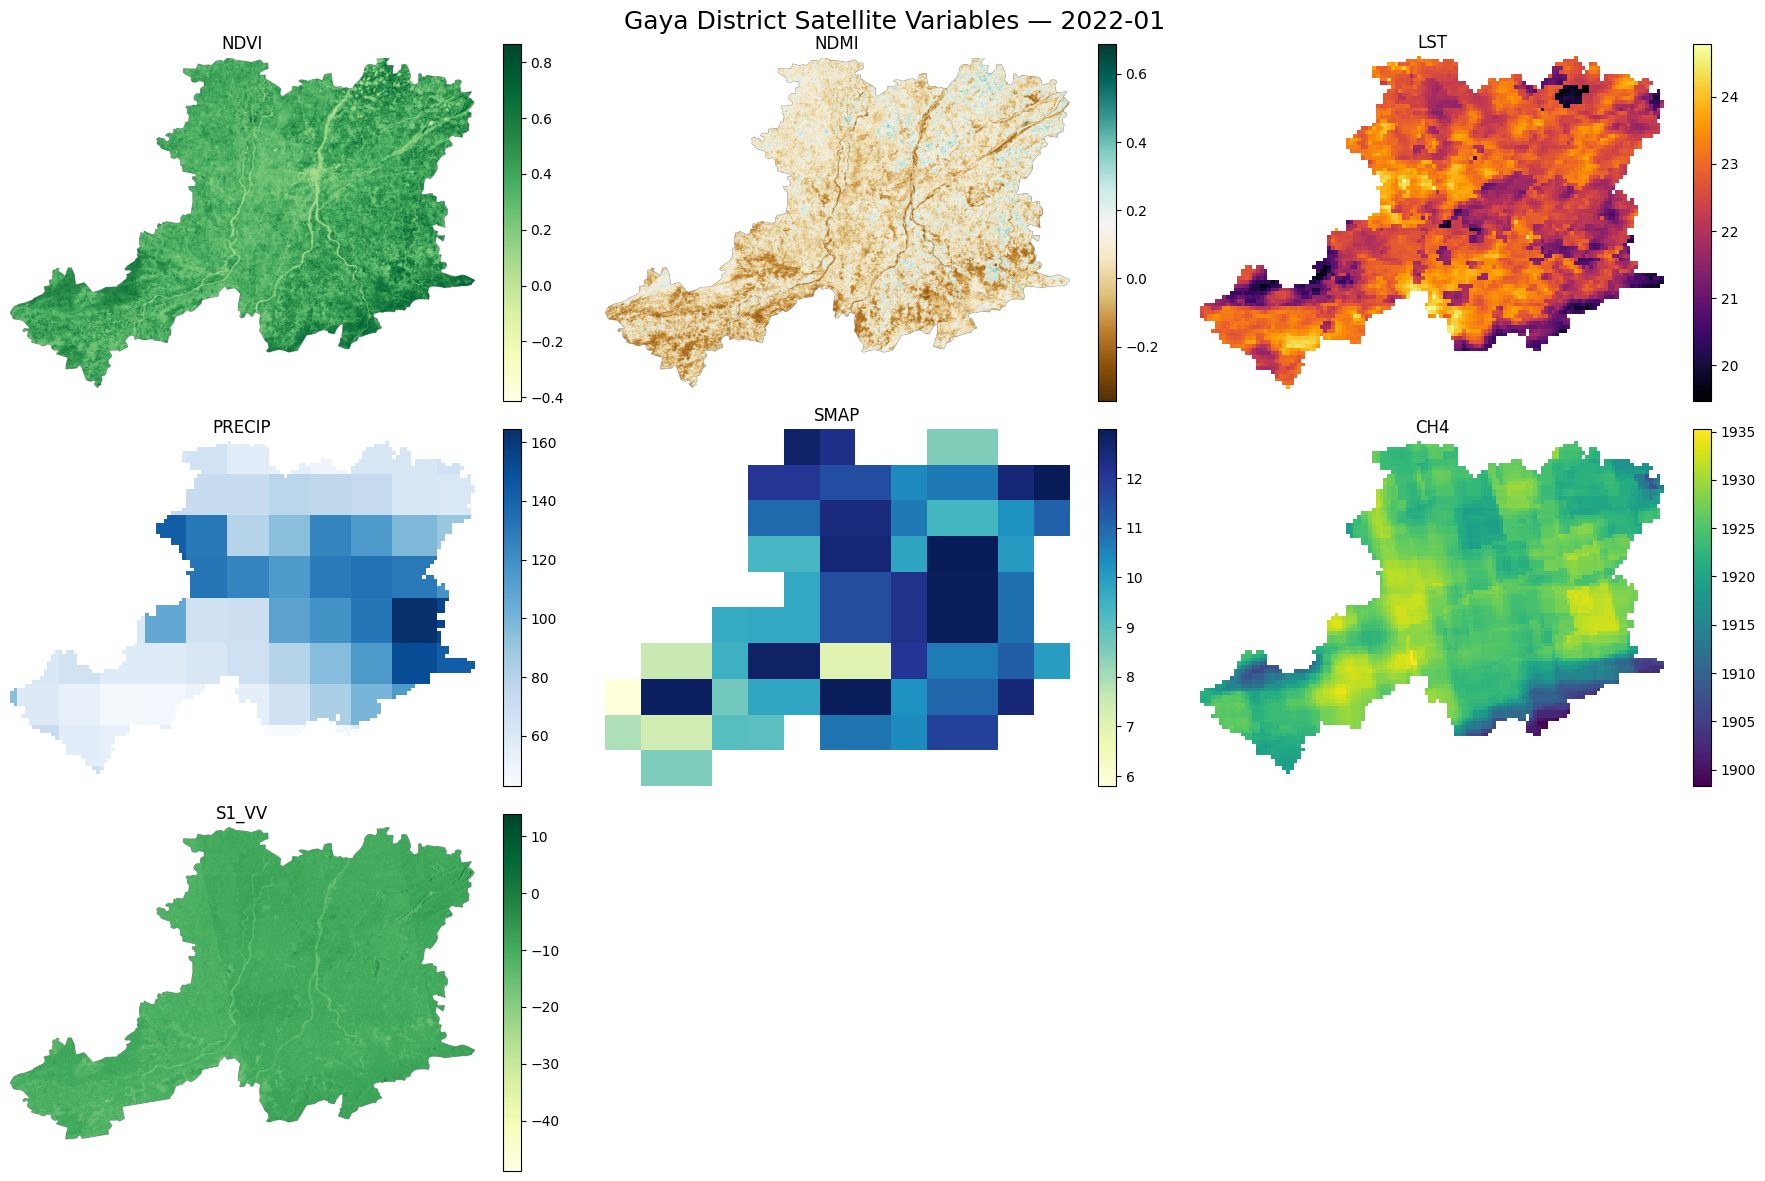

In [ ]:
!pip install rasterio
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import os

BASE_PATH = "/content/drive/MyDrive/mini_project_1"
YEAR = "2022"
MONTH = "01"

datasets = {
    "NDVI": (f"{BASE_PATH}/NDVI_NDMI_{YEAR}_{MONTH}.tif",1,"YlGn"),
    "NDMI": (f"{BASE_PATH}/NDVI_NDMI_{YEAR}_{MONTH}.tif",2,"BrBG"),
    "LST": (f"{BASE_PATH}/LST_{YEAR}_{MONTH}.tif",1,"inferno"),
    "PRECIP": (f"{BASE_PATH}/PRECIP_{YEAR}_{MONTH}.tif",1,"Blues"),
    "SMAP": (f"{BASE_PATH}/SMAP_{YEAR}_{MONTH}.tif",1,"YlGnBu"),
    "CH4": (f"{BASE_PATH}/CH4_{YEAR}_{MONTH}.tif",1,"viridis"),
    "S1_VV": (f"{BASE_PATH}/S1_{YEAR}_{MONTH}.tif",1,"YlGn"),
    "S1_VH": (f"{BASE_PATH}/S1_{YEAR}_{MONTH}.tif",2,"BrBG"),
}

plt.figure(figsize=(18,12))

i=1

for name,(path,band,cmap) in datasets.items():

    if not os.path.exists(path):
        print("Missing:",path)
        continue

    with rasterio.open(path) as src:
        data = src.read(band)

    plt.subplot(3,3,i)
    plt.imshow(data,cmap=cmap)
    plt.title(name)
    plt.colorbar()
    plt.axis("off")

    print(name,"range:",np.nanmin(data),"to",np.nanmax(data))

    i+=1

plt.suptitle(f"Gaya District Satellite Variables — {YEAR}-{MONTH}",fontsize=18)
plt.tight_layout()
plt.show()

In [ ]:
# CELL: Check all exported TIFF files for corruption before alignment

!pip install rasterio

import glob
import rasterio
import os
import numpy as np

BASE_PATH = "/content/drive/MyDrive/mini_project_1"
files = glob.glob(os.path.join(BASE_PATH, "*.tif"))

bad_files = []

for f in files:
    try:
        with rasterio.open(f) as src:
            data = src.read()   # read all bands
            np.nanmean(data)    # force full loading
    except Exception as e:
        print("Error in:", f)
        print(e)
        bad_files.append(f)

print("Corrupted files:")
print(bad_files)
print("Total bad:", len(bad_files))

/tmp/ipykernel_1317/1046658605.py:19: RuntimeWarning: Mean of empty slice
  np.nanmean(data)    # force full loading


Corrupted files:
[]
Total bad: 0


# ***Data Alignment & Final Dataset***

In [ ]:
# CELL 5: Align rasters and build final dataset

import rasterio
from rasterio.warp import reproject, Resampling
import glob
import numpy as np
import pandas as pd
import os

BASE_PATH = "/content/drive/MyDrive/mini_project_1"

nd_files = sorted(glob.glob(os.path.join(BASE_PATH, "NDVI_NDMI_*.tif")))

all_data = []

for nd_path in nd_files:

    filename = os.path.basename(nd_path)
    parts = filename.replace('.tif', '').split('_')
    year, month = int(parts[2]), int(parts[3])
    key = f"{year}_{month:02d}"

    lst_path = os.path.join(BASE_PATH, f"LST_{key}.tif")
    precip_path = os.path.join(BASE_PATH, f"PRECIP_{key}.tif")
    smap_path = os.path.join(BASE_PATH, f"SMAP_{key}.tif")
    s1_path = os.path.join(BASE_PATH, f"S1_{key}.tif")
    ch4_path = os.path.join(BASE_PATH, f"CH4_{key}.tif")

    if not os.path.exists(lst_path):
        print("Skipping (no LST):", key)
        continue

    #  Read LST as master grid
    with rasterio.open(lst_path) as lst_src:
        lst = lst_src.read(1).astype(np.float32)
        dst_transform = lst_src.transform
        dst_crs = lst_src.crs
        dst_shape = lst.shape

    #  Reprojection function
    def reproject_to_lst(src_path, band=1):
        if not os.path.exists(src_path):
            return np.full(dst_shape, np.nan, dtype=np.float32)

        dst_array = np.full(dst_shape, np.nan, dtype=np.float32)

        with rasterio.open(src_path) as src:
            reproject(
                source=rasterio.band(src, band),
                destination=dst_array,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=dst_transform,
                dst_crs=dst_crs,
                resampling=Resampling.average,
                dst_nodata=np.nan
            )
        return dst_array

    #  Reproject all layers
    ndvi = reproject_to_lst(nd_path, 1)
    ndmi = reproject_to_lst(nd_path, 2)
    precip = reproject_to_lst(precip_path)
    smap = reproject_to_lst(smap_path)
    vv = reproject_to_lst(s1_path, 1)
    vh = reproject_to_lst(s1_path, 2)
    ch4 = reproject_to_lst(ch4_path)

    #  Flatten
    ndvi = ndvi.ravel()
    ndmi = ndmi.ravel()
    lst = lst.ravel()
    precip = precip.ravel()
    smap = smap.ravel()
    vv = vv.ravel()
    vh = vh.ravel()
    ch4 = ch4.ravel()

    #  Ratio
    vv_vh_ratio = vv / (vh + 1e-6)

    #  Strong valid mask + physical limits
    valid = (
        (ndvi > -1) & (ndvi < 1) &
        (ndmi > -1) & (ndmi < 1) &
        (lst > -50) & (lst < 70) &
        ~np.isnan(precip) &
        ~np.isnan(smap) &
        ~np.isnan(vv) &
        ~np.isnan(vh) &
        ~np.isnan(ch4)
    )

    if valid.sum() == 0:
        print("No valid pixels:", key)
        continue

    #  Build DataFrame
    chunk_df = pd.DataFrame({
        "year": year,
        "month": month,
        "ndvi": ndvi[valid],
        "lst": lst[valid],
        "precip": precip[valid],
        "smap": smap[valid],
        "vv": vv[valid],
        "vh": vh[valid],
        "vv_vh_ratio": vv_vh_ratio[valid],
        "ch4": ch4[valid],
        "ndmi": ndmi[valid]
    })

    all_data.append(chunk_df)

    print(f"Aligned & processed: {key} | Pixels: {valid.sum()}")

#  Combine all months
df = pd.concat(all_data, ignore_index=True)

# Ensure numeric dtype
df = df.astype({
    "year": "int32",
    "month": "int32",
    "ndvi": "float32",
    "lst": "float32",
    "precip": "float32",
    "smap": "float32",
    "vv": "float32",
    "vh": "float32",
    "vv_vh_ratio": "float32",
    "ch4": "float32",
    "ndmi": "float32"
})

#  Save CSV
csv_path = os.path.join(BASE_PATH, "Final_dataset.csv")
df.to_csv(csv_path, index=False)

print("\nDataset saved at:", csv_path)
print("Total rows:", len(df))
print("CSV size (MB):", round(os.path.getsize(csv_path)/1e6, 2))

No valid pixels: 2017_01
No valid pixels: 2017_02
No valid pixels: 2017_03
No valid pixels: 2017_04
No valid pixels: 2017_05
No valid pixels: 2017_06
No valid pixels: 2017_10
No valid pixels: 2017_11
No valid pixels: 2017_12
No valid pixels: 2018_01
No valid pixels: 2018_02
No valid pixels: 2018_03
No valid pixels: 2018_04
No valid pixels: 2018_05
No valid pixels: 2018_06
No valid pixels: 2018_10
No valid pixels: 2018_11
Aligned & processed: 2018_12 | Pixels: 458
Aligned & processed: 2019_01 | Pixels: 1898
Aligned & processed: 2019_02 | Pixels: 2257
Aligned & processed: 2019_03 | Pixels: 1909
Aligned & processed: 2019_04 | Pixels: 3631
Aligned & processed: 2019_05 | Pixels: 5123
Aligned & processed: 2019_06 | Pixels: 5083
No valid pixels: 2019_07
No valid pixels: 2019_08
No valid pixels: 2019_09
Aligned & processed: 2019_10 | Pixels: 733
Aligned & processed: 2019_11 | Pixels: 2194
Aligned & processed: 2019_12 | Pixels: 1549
Aligned & processed: 2020_01 | Pixels: 2258
Aligned & processe

In [ ]:
from google.colab import drive
drive.flush_and_unmount()

import os
os.path.exists('/content/drive')

Drive not mounted, so nothing to flush and unmount.


False

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# ***EDA***

In [ ]:
import pandas as pd

BASE_PATH = "/content/drive/MyDrive/mini_project_1"
csv_path = f"{BASE_PATH}/Final_dataset.csv"

df = pd.read_csv(csv_path)

In [ ]:
print(df)

        year  month      ndvi     lst     precip      smap         vv  \
0       2018     12  0.255500  23.115  23.969248  6.796112  -9.963915   
1       2018     12  0.297833  22.895  23.969248  6.796112 -10.090527   
2       2018     12  0.263775  22.980  23.969248  6.796112 -10.937494   
3       2018     12  0.288436  22.860  23.276050  4.211166 -10.167234   
4       2018     12  0.293319  22.860  23.276050  4.211166 -10.111471   
...      ...    ...       ...     ...        ...       ...        ...   
123412  2022      5  0.257267  40.450  63.646360  2.297281 -12.694113   
123413  2022      5  0.193710  40.400  63.419327  2.297281 -13.409488   
123414  2022      5  0.294602  39.845  63.419327  2.297281 -12.148995   
123415  2022      5  0.249277  39.385  63.646360  2.339106 -12.773063   
123416  2022      5  0.236048  40.080  63.646360  2.339106 -13.359109   

               vh  vv_vh_ratio        ch4      ndmi  
0      -17.883770     0.557149  1880.9319 -0.051471  
1      -17.6847

In [ ]:
print("Total rows:", len(df))
print(df['year'].min(), df['year'].max())
print(df.groupby('year').size())

Total rows: 123417
2018 2022
year
2018      458
2019    24377
2020    32638
2021    40406
2022    25538
dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123417 entries, 0 to 123416
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   year         123417 non-null  int64  
 1   month        123417 non-null  int64  
 2   ndvi         123417 non-null  float64
 3   lst          123417 non-null  float64
 4   precip       123417 non-null  float64
 5   smap         123417 non-null  float64
 6   vv           123417 non-null  float64
 7   vh           123417 non-null  float64
 8   vv_vh_ratio  123417 non-null  float64
 9   ch4          123417 non-null  float64
 10  ndmi         123417 non-null  float64
dtypes: float64(9), int64(2)
memory usage: 10.4 MB


In [ ]:
df.describe()

,year,month,ndvi,lst,precip,smap,vv,vh,vv_vh_ratio,ch4,ndmi
count,123417.000000,123417.000000,123417.000000,123417.000000,123417.000000,123417.000000,123417.000000,123417.000000,123417.000000,123417.000000,123417.000000
mean,2020.536304,5.539302,0.383337,32.020757,65.680941,6.631122,-11.269409,-18.430882,0.611632,1909.953135,0.001144
std,1.039154,3.765702,0.155359,7.450285,95.625145,4.990546,1.302824,1.914278,0.037157,23.689460,0.132203
min,2018.000000,1.000000,0.030526,18.070000,0.000000,1.847273,-17.989859,-28.059113,0.422770,1838.228500,-0.281060
25%,2020.000000,3.000000,0.255699,25.100000,4.715836,2.733510,-12.103478,-19.570436,0.585849,1890.086900,-0.108948
50%,2021.000000,4.000000,0.348486,29.910000,27.578005,4.487300,-11.334920,-18.346334,0.611175,1910.184100,-0.028362
75%,2021.000000,10.000000,0.503873,39.610000,96.919520,9.058592,-10.477659,-17.213655,0.638429,1925.820000,0.097336
max,2022.000000,12.000000,0.843587,49.090000,784.970300,24.860933,-5.034234,-11.543833,0.754885,1977.785800,0.439209


In [ ]:
df.corr()

,year,month,ndvi,lst,precip,smap,vv,vh,vv_vh_ratio,ch4,ndmi
year,1.000000,-0.233523,0.195390,-0.121004,0.034792,0.037808,0.101836,0.140713,0.036754,0.478882,0.142385
month,-0.233523,1.000000,-0.022144,-0.170256,0.017134,0.383814,0.239564,0.165860,-0.173145,0.555494,0.103706
ndvi,0.195390,-0.022144,1.000000,-0.487152,0.052319,0.559348,0.318766,0.618540,0.435344,0.206294,0.905211
lst,-0.121004,-0.170256,-0.487152,1.000000,0.089993,-0.430483,-0.387850,-0.435586,0.014854,-0.299010,-0.589572
precip,0.034792,0.017134,0.052319,0.089993,1.000000,0.453477,0.108776,0.047730,-0.124473,0.007401,0.045794
smap,0.037808,0.383814,0.559348,-0.430483,0.453477,1.000000,0.403636,0.455031,-0.003001,0.483117,0.601752
vv,0.101836,0.239564,0.318766,-0.387850,0.108776,0.403636,1.000000,0.856065,-0.471443,0.243001,0.279449
vh,0.140713,0.165860,0.618540,-0.435586,0.047730,0.455031,0.856065,1.000000,0.049312,0.226215,0.515380
vv_vh_ratio,0.036754,-0.173145,0.435344,0.014854,-0.124473,-0.003001,-0.471443,0.049312,1.000000,-0.079113,0.337810
ch4,0.478882,0.555494,0.206294,-0.299010,0.007401,0.483117,0.243001,0.226215,-0.079113,1.000000,0.315218


In [ ]:
# CELL: Basic dataset summary and yearly distribution check

print("Total rows:", len(df))
print(df['year'].min(), df['year'].max())
print(df.groupby('year').size())

df
df.info()
df.describe()
df.corr()

Total rows: 123417
2018 2022
year
2018      458
2019    24377
2020    32638
2021    40406
2022    25538
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123417 entries, 0 to 123416
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   year         123417 non-null  int64  
 1   month        123417 non-null  int64  
 2   ndvi         123417 non-null  float64
 3   lst          123417 non-null  float64
 4   precip       123417 non-null  float64
 5   smap         123417 non-null  float64
 6   vv           123417 non-null  float64
 7   vh           123417 non-null  float64
 8   vv_vh_ratio  123417 non-null  float64
 9   ch4          123417 non-null  float64
 10  ndmi         123417 non-null  float64
dtypes: float64(9), int64(2)
memory usage: 10.4 MB


,year,month,ndvi,lst,precip,smap,vv,vh,vv_vh_ratio,ch4,ndmi
year,1.000000,-0.233523,0.195390,-0.121004,0.034792,0.037808,0.101836,0.140713,0.036754,0.478882,0.142385
month,-0.233523,1.000000,-0.022144,-0.170256,0.017134,0.383814,0.239564,0.165860,-0.173145,0.555494,0.103706
ndvi,0.195390,-0.022144,1.000000,-0.487152,0.052319,0.559348,0.318766,0.618540,0.435344,0.206294,0.905211
lst,-0.121004,-0.170256,-0.487152,1.000000,0.089993,-0.430483,-0.387850,-0.435586,0.014854,-0.299010,-0.589572
precip,0.034792,0.017134,0.052319,0.089993,1.000000,0.453477,0.108776,0.047730,-0.124473,0.007401,0.045794
smap,0.037808,0.383814,0.559348,-0.430483,0.453477,1.000000,0.403636,0.455031,-0.003001,0.483117,0.601752
vv,0.101836,0.239564,0.318766,-0.387850,0.108776,0.403636,1.000000,0.856065,-0.471443,0.243001,0.279449
vh,0.140713,0.165860,0.618540,-0.435586,0.047730,0.455031,0.856065,1.000000,0.049312,0.226215,0.515380
vv_vh_ratio,0.036754,-0.173145,0.435344,0.014854,-0.124473,-0.003001,-0.471443,0.049312,1.000000,-0.079113,0.337810
ch4,0.478882,0.555494,0.206294,-0.299010,0.007401,0.483117,0.243001,0.226215,-0.079113,1.000000,0.315218


In [ ]:
# Cell 6: PREPARE TRAINING ARRAYS

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib

# Load FINAL dataset
BASE_PATH = "/content/drive/MyDrive/mini_project_1"
csv_path = f"{BASE_PATH}/Final_dataset.csv"

df = pd.read_csv(csv_path)
print("Dataset shape:", df.shape)
print("Year range:", df['year'].min(), "-", df['year'].max())

# Drop rows where target is NaN
df = df.dropna(subset=['ndmi'])

#feature names
features = [
    'ndvi',
    'lst',
    'precip',
    'smap',
    'vv',
    'vh',
    'vv_vh_ratio',
    'ch4',
    'year',
    'month'
]

target = 'ndmi'

# TIME-BASED SPLIT
# Train: 2018–2021
# Test: 2022

train_df = df[df['year'] <= 2021]
test_df  = df[df['year'] == 2022]

X_train = train_df[features].values
y_train = train_df[target].values

X_test = test_df[features].values
y_test = test_df[target].values

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# SCALING (FIT ONLY ON TRAIN)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save scaler
joblib.dump(scaler, f"{BASE_PATH}/scaler.joblib")

print("Preprocessing complete.")

Dataset shape: (123417, 11)
Year range: 2018 - 2022
Train shape: (97879, 10)
Test shape: (25538, 10)
Preprocessing complete.


# ***Models - LightGBM***

In [ ]:
# CELL 7A : Train LightGBM regression model

from lightgbm import LGBMRegressor
import joblib

# Define LightGBM model
lgbm = LGBMRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

# Train model
lgbm.fit(X_train, y_train)

# Save trained model
joblib.dump(lgbm, f"{BASE_PATH}/lightgbm_final.joblib")

print("LightGBM model saved to Drive.")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003932 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2056
[LightGBM] [Info] Number of data points in the train set: 97879, number of used features: 10
[LightGBM] [Info] Start training from score 0.001100
LightGBM model saved to Drive.


In [ ]:
# CELL 8A : Evaluate trained LightGBM model on both training and test datasets

import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib

# Load trained model
model = joblib.load(f"{BASE_PATH}/lightgbm_final.joblib")

# Train predictions
y_train_pred = model.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)

# Test predictions
y_test_pred = model.predict(X_test)
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

# Print results
print("________ TRAIN PERFORMANCE ________")
print("R2:", train_r2)
print("RMSE:", train_rmse)
print("MAE:", train_mae)

print("\n________ TEST PERFORMANCE ________")
print("R2:", test_r2)
print("RMSE:", test_rmse)
print("MAE:", test_mae)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


________ TRAIN PERFORMANCE ________
R2: 0.9736297031339662
RMSE: 0.021707913945019308
MAE: 0.015884142708120722

________ TEST PERFORMANCE ________
R2: 0.8922995478840459
RMSE: 0.041476739694151145
MAE: 0.02987157460776288


In [ ]:
# CELL 9A : Compute permutation importance on test set and derive DI weights

import pandas as pd
import numpy as np
from sklearn.inspection import permutation_importance
import joblib

BASE_PATH = "/content/drive/MyDrive/mini_project_1"   # corrected folder

# Load trained model
model = joblib.load(f"{BASE_PATH}/lightgbm_final.joblib")

# Feature names (must match training order)
feature_names = [
    'ndvi',
    'lst',
    'precip',
    'smap',
    'vv',
    'vh',
    'vv_vh_ratio',
    'ch4',
    'year',
    'month'
]

# Compute permutation importance on TEST SET
result = permutation_importance(
    model,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='r2',
    n_jobs=-1
)

# Build importance DataFrame
imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
})

imp_df = imp_df.sort_values(by='importance_mean', ascending=False)

print("Permutation Importance (based on R2 drop):")
print(imp_df)

# Normalize positive importances for DI weights
imp_df['importance_positive'] = imp_df['importance_mean'].clip(lower=0)
total = imp_df['importance_positive'].sum()
imp_df['norm_weight'] = imp_df['importance_positive'] / total

print("\nNormalized Weights (for DI):")
print(imp_df[['feature','norm_weight']])

# Save importance file
imp_df.to_csv(f"{BASE_PATH}/feature_importance_lightgbm.csv", index=False)

print("\nSaved feature importance to Drive.")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Permutation Importance (based on R2 drop):
       feature  importance_mean  importance_std
0         ndvi         2.411030        0.011983
6  vv_vh_ratio         0.062616        0.001521
1          lst         0.000000        0.000000
3         smap         0.000000        0.000000
5           vh         0.000000        0.000000
4           vv         0.000000        0.000000
8         year         0.000000        0.000000
7          ch4         0.000000        0.000000
9        month         0.000000        0.000000
2       precip        -0.001056        0.000113

Normalized Weights (for DI):
       feature  norm_weight
0         ndvi     0.974687
6  vv_vh_ratio     0.025313
1          lst     0.000000
3         smap     0.000000
5           vh     0.000000
4           vv     0.000000
8         year     0.000000
7          ch4     0.000000
9        month     0.000000
2       precip     0.000000

Saved feature importance to Drive.


# ***Models - MLP***

In [ ]:
# CELL 7B : Train MLP regression model

from sklearn.neural_network import MLPRegressor
import joblib

# Number of features
n_features = X_train_scaled.shape[1]

# Define MLP model
mlp = MLPRegressor(
            hidden_layer_sizes=(256,128,64),
            activation='relu',
            max_iter=1000,
            early_stopping=True,
            random_state=42
        )

mlp.fit(X_train_scaled, y_train)

# Save trained model
joblib.dump(mlp, f"{BASE_PATH}/dlmlp_final.joblib")

print("Model saved to Drive.")

Model saved to Drive.


In [ ]:
# CELL 8B : Evaluate trained MLP model on both training and test datasets

import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib

# Load trained model
model = joblib.load(f"{BASE_PATH}/dlmlp_final.joblib")

# Train predictions
y_train_pred = model.predict(X_train_scaled)
train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)

# Test predictions
y_test_pred = model.predict(X_test_scaled)
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

# Print results
print("________ TRAIN PERFORMANCE ________")
print("R2:", train_r2)
print("RMSE:", train_rmse)
print("MAE:", train_mae)

print("\n________ TEST PERFORMANCE ________")
print("R2:", test_r2)
print("RMSE:", test_rmse)
print("MAE:", test_mae)

________ TRAIN PERFORMANCE ________
R2: 0.9731739853873147
RMSE: 0.021894682926007526
MAE: 0.015931443225000768

________ TEST PERFORMANCE ________
R2: 0.8167553712706432
RMSE: 0.05410177010003507
MAE: 0.039888184446491046


In [ ]:
# CELL 9B : Compute permutation importance on test set and derive DI weights

import pandas as pd
import numpy as np
from sklearn.inspection import permutation_importance
import joblib

BASE_PATH = "/content/drive/MyDrive/mini_project_1"   # corrected folder

# Load trained model
model = joblib.load(f"{BASE_PATH}/dlmlp_final.joblib")

# Feature names (must match training order)
feature_names = [
    'ndvi',
    'lst',
    'precip',
    'smap',
    'vv',
    'vh',
    'vv_vh_ratio',
    'ch4',
    'year',
    'month'
]

# Compute permutation importance on TEST SET
result = permutation_importance(
    model,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='r2',
    n_jobs=-1
)

# Build importance DataFrame
imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
})

imp_df = imp_df.sort_values(by='importance_mean', ascending=False)

print("Permutation Importance (based on R2 drop):")
print(imp_df)

# Normalize positive importances for DI weights
imp_df['importance_positive'] = imp_df['importance_mean'].clip(lower=0)
total = imp_df['importance_positive'].sum()
imp_df['norm_weight'] = imp_df['importance_positive'] / total

print("\nNormalized Weights (for DI):")
print(imp_df[['feature','norm_weight']])

# Save importance file
imp_df.to_csv(f"{BASE_PATH}/feature_importance_dlmlp .csv", index=False)

print("\nSaved feature importance to Drive.")

Permutation Importance (based on R2 drop):
       feature  importance_mean  importance_std
0         ndvi         1.331485        0.006977
1          lst         0.268086        0.002254
6  vv_vh_ratio         0.088332        0.001497
4           vv         0.043846        0.000544
5           vh         0.039085        0.001197
7          ch4         0.019884        0.000759
3         smap         0.016277        0.000597
8         year         0.000000        0.000000
9        month        -0.013450        0.000970
2       precip        -0.023599        0.001165

Normalized Weights (for DI):
       feature  norm_weight
0         ndvi     0.736850
1          lst     0.148360
6  vv_vh_ratio     0.048884
4           vv     0.024265
5           vh     0.021630
7          ch4     0.011004
3         smap     0.009008
8         year     0.000000
9        month     0.000000
2       precip     0.000000

Saved feature importance to Drive.


# ***Model Comparision***

In [ ]:
# MODEL COMPARISON + SAVE TRAINED MODELS

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import lightgbm as lgb
import numpy as np
import pandas as pd
import joblib

models = {

    "Linear Regression":
        LinearRegression(),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ),

    "Extra Trees":
        ExtraTreesRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ),

    "XGBoost":
        xgb.XGBRegressor(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        ),

    "LightGBM":
        lgb.LGBMRegressor(
            n_estimators=400,
            learning_rate=0.05,
            random_state=42
        ),

    "MLP":
        MLPRegressor(
            hidden_layer_sizes=(256,128,64),
            activation='relu',
            max_iter=1000,
            early_stopping=True,
            random_state=42
        )
}

results = []

for name, model in models.items():

    print(f"Training {name}...")

    # Tree models do not need scaling
    if name in ["Random Forest","Extra Trees","Gradient Boosting","XGBoost","LightGBM"]:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    else:
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)

    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)

    results.append([name, r2, rmse, mae])

    # Save trained model
    model_filename = name.lower().replace(" ", "_") + "_model.joblib"
    joblib.dump(model, f"{BASE_PATH}/{model_filename}")

    print(f"{name} model saved to Drive.")

results_df = pd.DataFrame(results, columns=["Model","R2","RMSE","MAE"])
print("\nModel Comparison:")
print(results_df.sort_values("R2", ascending=False))

Training Linear Regression...
Linear Regression model saved to Drive.
Training Random Forest...
Random Forest model saved to Drive.
Training Extra Trees...
Extra Trees model saved to Drive.
Training Gradient Boosting...
Gradient Boosting model saved to Drive.
Training XGBoost...
XGBoost model saved to Drive.
Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003947 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2056
[LightGBM] [Info] Number of data points in the train set: 97879, number of used features: 10
[LightGBM] [Info] Start training from score 0.001100


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM model saved to Drive.
Training MLP...
MLP model saved to Drive.

Model Comparison:
               Model        R2      RMSE       MAE
5           LightGBM  0.892300  0.041477  0.029872
1      Random Forest  0.891158  0.041696  0.030451
4            XGBoost  0.885914  0.042689  0.031668
2        Extra Trees  0.880579  0.043675  0.031226
3  Gradient Boosting  0.872691  0.045095  0.032381
0  Linear Regression  0.825270  0.052830  0.038444
6                MLP  0.816755  0.054102  0.039888


In [ ]:
# Evaluate trained models on both training and test datasets

import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib

BASE_PATH = "/content/drive/MyDrive/mini_project_1"

# Load trained model
model = joblib.load(f"{BASE_PATH}/random_forest_model.joblib")

# Train predictions
y_train_pred = model.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)

# Test predictions
y_test_pred = model.predict(X_test)
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

# Print results
print("________ TRAIN PERFORMANCE ________")
print("R2:", train_r2)
print("RMSE:", train_rmse)
print("MAE:", train_mae)

print("\n________ TEST PERFORMANCE ________")
print("R2:", test_r2)
print("RMSE:", test_rmse)
print("MAE:", test_mae)

________ TRAIN PERFORMANCE ________
R2: 0.996178506533
RMSE: 0.00826374947436178
MAE: 0.005717997548591547

________ TEST PERFORMANCE ________
R2: 0.891157824999508
RMSE: 0.04169600572978612
MAE: 0.03045090393646159


In [ ]:
# CELL  : Compute permutation importance on test set and derive DI weights

import pandas as pd
import numpy as np
from sklearn.inspection import permutation_importance
import joblib

BASE_PATH = "/content/drive/MyDrive/mini_project_1"   # corrected folder

# Load trained model
model = joblib.load(f"{BASE_PATH}/random_forest_model.joblib")

# Feature names (must match training order)
feature_names = [
    'ndvi',
    'lst',
    'precip',
    'smap',
    'vv',
    'vh',
    'vv_vh_ratio',
    'ch4',
    'year',
    'month'
]

# Compute permutation importance on TEST SET
result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='r2',
    n_jobs=-1
)

# Build importance DataFrame
imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
})

imp_df = imp_df.sort_values(by='importance_mean', ascending=False)

print("Permutation Importance (based on R2 drop):")
print(imp_df)

# Normalize positive importances for DI weights
imp_df['importance_positive'] = imp_df['importance_mean'].clip(lower=0)
total = imp_df['importance_positive'].sum()
imp_df['norm_weight'] = imp_df['importance_positive'] / total

print("\nNormalized Weights (for DI):")
print(imp_df[['feature','norm_weight']])

# Save importance file
imp_df.to_csv(f"{BASE_PATH}/feature_importance_random_forest.csv", index=False)

print("\nSaved feature importance to Drive.")

  # ***Drought Index & Drought Map***

In [ ]:
!pip install rasterio

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#DI for any particular month

import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
import joblib
import os

BASE_PATH = "/content/drive/MyDrive/mini_project_1"

# Load permutation weights
imp_df = pd.read_csv(f"{BASE_PATH}/feature_importance_lightgbm.csv")

# Remove non-physical features
imp_df = imp_df[~imp_df['feature'].isin(['year', 'month'])]

if 'norm_weight' in imp_df.columns:
    weights = dict(zip(imp_df['feature'], imp_df['norm_weight']))
else:
    imp_df['importance_positive'] = imp_df['importance_mean'].clip(lower=0)
    total = imp_df['importance_positive'].sum()
    weights = dict(zip(
        imp_df['feature'],
        imp_df['importance_positive'] / total
    ))

print("Using weights:", weights)

# Load scaler

scaler = joblib.load(f"{BASE_PATH}/scaler.joblib")

# Select month
key = "2020_05"   # change month

lst_path = f"{BASE_PATH}/LST_{key}.tif"

with rasterio.open(lst_path) as lst_src:
    lst = lst_src.read(1).astype("float32")
    dst_transform = lst_src.transform
    dst_crs = lst_src.crs
    dst_shape = lst.shape
    meta = lst_src.meta

# Reprojection function
def reproject_to_lst(src_path, band=1):
    if not os.path.exists(src_path):
        return np.full(dst_shape, np.nan, dtype="float32")

    dst_array = np.full(dst_shape, np.nan, dtype="float32")

    with rasterio.open(src_path) as src:
        reproject(
            source=rasterio.band(src, band),
            destination=dst_array,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            resampling=Resampling.bilinear,
            dst_nodata=np.nan
        )
    return dst_array

# Load variables
nd_path = f"{BASE_PATH}/NDVI_NDMI_{key}.tif"
precip_path = f"{BASE_PATH}/PRECIP_{key}.tif"
smap_path = f"{BASE_PATH}/SMAP_{key}.tif"
s1_path = f"{BASE_PATH}/S1_{key}.tif"
ch4_path = f"{BASE_PATH}/CH4_{key}.tif"

ndvi = reproject_to_lst(nd_path, 1)
vv = reproject_to_lst(s1_path, 1)
vh = reproject_to_lst(s1_path, 2)
precip = reproject_to_lst(precip_path)
smap = reproject_to_lst(smap_path)
ch4 = reproject_to_lst(ch4_path)

vv_vh_ratio = vv / (vh + 1e-6)

year_val = int(key.split("_")[0])
month_val = int(key.split("_")[1])

year = np.full(dst_shape, year_val, dtype="float32")
month = np.full(dst_shape, month_val, dtype="float32")

# Stack features
feature_stack = np.stack([
    ndvi,
    lst,
    precip,
    smap,
    vv,
    vh,
    vv_vh_ratio,
    ch4,
    year,
    month
], axis=-1)

flat = feature_stack.reshape(-1, feature_stack.shape[-1])

flat_scaled = scaler.transform(flat)

scaled_stack = flat_scaled.reshape(
    dst_shape[0],
    dst_shape[1],
    -1
)

# Compute DI (correct drought direction)
feature_order = [
    'ndvi','lst','precip','smap',
    'vv','vh','vv_vh_ratio','ch4',
    'year','month'
]

DI = np.zeros(dst_shape, dtype="float32")

for i, fname in enumerate(feature_order):

    if fname not in weights:
        continue

    # Flip vegetation & rainfall because high values reduce drought
    if fname in ['ndvi', 'precip', 'smap']:
        DI -= weights[fname] * scaled_stack[:, :, i]
    else:
        DI += weights[fname] * scaled_stack[:, :, i]

# Standardize DI
mean = np.nanmean(DI)
std = np.nanstd(DI)

if std != 0:
    DI = (DI - mean) / std

# Save DI raster
meta.update({'count': 1, 'dtype': 'float32'})

out_path = f"{BASE_PATH}/DI_{key}.tif"

with rasterio.open(out_path, 'w', **meta) as dst:
    dst.write(np.nan_to_num(DI, nan=-9999).astype('float32'), 1)

print("DI saved at:", out_path)

Using weights: {'ndvi': 0.9746867263042814, 'vv_vh_ratio': 0.0253132736957186, 'lst': 0.0, 'smap': 0.0, 'vh': 0.0, 'vv': 0.0, 'ch4': 0.0, 'precip': 0.0}
DI saved at: /content/drive/MyDrive/mini_project_1/DI_2020_05.tif


In [ ]:
# GENERATE DI MAPS FOR ALL MONTHS (FULL DISTRICT)

import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
import joblib
import os
import glob

BASE_PATH = "/content/drive/MyDrive/mini_project_1"

# Load weights

imp_df = pd.read_csv(f"{BASE_PATH}/feature_importance_lightgbm.csv")
imp_df = imp_df[~imp_df['feature'].isin(['year','month'])]

if 'norm_weight' in imp_df.columns:
    weights = dict(zip(imp_df['feature'], imp_df['norm_weight']))
else:
    imp_df['importance_positive'] = imp_df['importance_mean'].clip(lower=0)
    total = imp_df['importance_positive'].sum()
    weights = dict(zip(
        imp_df['feature'],
        imp_df['importance_positive'] / total
    ))

print("Using weights:", weights)

# Load scaler
scaler = joblib.load(f"{BASE_PATH}/scaler.joblib")

# Get all months from ND files
nd_files = sorted(glob.glob(os.path.join(BASE_PATH, "NDVI_NDMI_*.tif")))

print("Total months found:", len(nd_files))

# Loop through all months
for nd_path in nd_files:

    filename = os.path.basename(nd_path)
    parts = filename.replace('.tif','').split('_')
    key = f"{parts[2]}_{parts[3]}"

    print("Processing:", key)

    lst_path = f"{BASE_PATH}/LST_{key}.tif"
    precip_path = f"{BASE_PATH}/PRECIP_{key}.tif"
    smap_path = f"{BASE_PATH}/SMAP_{key}.tif"
    s1_path = f"{BASE_PATH}/S1_{key}.tif"
    ch4_path = f"{BASE_PATH}/CH4_{key}.tif"

    if not os.path.exists(lst_path):
        print("Skipping:", key)
        continue

    with rasterio.open(lst_path) as lst_src:
        lst = lst_src.read(1).astype("float32")
        dst_transform = lst_src.transform
        dst_crs = lst_src.crs
        dst_shape = lst.shape
        meta = lst_src.meta

    # Reprojection function
    def reproject_to_lst(src_path, band=1):
        if not os.path.exists(src_path):
            return np.full(dst_shape, np.nan, dtype="float32")

        dst_array = np.full(dst_shape, np.nan, dtype="float32")

        with rasterio.open(src_path) as src:
            reproject(
                source=rasterio.band(src, band),
                destination=dst_array,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=dst_transform,
                dst_crs=dst_crs,
                resampling=Resampling.bilinear,
                dst_nodata=np.nan
            )
        return dst_array

    # Load variables
    ndvi = reproject_to_lst(nd_path, 1)
    vv = reproject_to_lst(s1_path, 1)
    vh = reproject_to_lst(s1_path, 2)
    precip = reproject_to_lst(precip_path)
    smap = reproject_to_lst(smap_path)
    ch4 = reproject_to_lst(ch4_path)

    vv_vh_ratio = vv / (vh + 1e-6)

    year_val = int(parts[2])
    month_val = int(parts[3])

    year = np.full(dst_shape, year_val, dtype="float32")
    month = np.full(dst_shape, month_val, dtype="float32")

    # Stack features (training order)
    feature_stack = np.stack([
        ndvi, lst, precip, smap,
        vv, vh, vv_vh_ratio, ch4,
        year, month
    ], axis=-1)

    flat = feature_stack.reshape(-1, feature_stack.shape[-1])
    flat_scaled = scaler.transform(flat)

    scaled_stack = flat_scaled.reshape(
        dst_shape[0],
        dst_shape[1],
        -1
    )

    # Compute DI (correct direction)
    feature_order = [
        'ndvi','lst','precip','smap',
        'vv','vh','vv_vh_ratio','ch4',
        'year','month'
    ]

    DI = np.zeros(dst_shape, dtype="float32")

    for i, fname in enumerate(feature_order):
        if fname not in weights:
            continue

        if fname in ['ndvi','precip','smap']:
            DI -= weights[fname] * scaled_stack[:,:,i]
        else:
            DI += weights[fname] * scaled_stack[:,:,i]

    # Standardize
    mean = np.nanmean(DI)
    std = np.nanstd(DI)
    if std != 0:
        DI = (DI - mean) / std

    # Save DI raster
    meta.update({'count':1, 'dtype':'float32'})
    out_path = f"{BASE_PATH}/DI_{key}.tif"

    with rasterio.open(out_path, 'w', **meta) as dst:
        dst.write(np.nan_to_num(DI, nan=-9999).astype('float32'), 1)

    print("Saved:", out_path)

print("All DI maps generated.")

Using weights: {'ndvi': 0.9746867263042814, 'vv_vh_ratio': 0.0253132736957186, 'lst': 0.0, 'smap': 0.0, 'vh': 0.0, 'vv': 0.0, 'ch4': 0.0, 'precip': 0.0}
Total months found: 102
Processing: 2017_01


/tmp/ipykernel_1317/755859219.py:135: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(DI)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Saved: /content/drive/MyDrive/mini_project_1/DI_2017_01.tif
Processing: 2017_02


/tmp/ipykernel_1317/755859219.py:135: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(DI)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Saved: /content/drive/MyDrive/mini_project_1/DI_2017_02.tif
Processing: 2017_03


...

/tmp/ipykernel_1317/755859219.py:135: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(DI)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Saved: /content/drive/MyDrive/mini_project_1/DI_2022_09.tif
Processing: 2022_10


/tmp/ipykernel_1317/755859219.py:135: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(DI)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Saved: /content/drive/MyDrive/mini_project_1/DI_2022_10.tif
Processing: 2022_11
Saved: /content/drive/MyDrive/mini_project_1/DI_2022_11.tif
Processing: 2022_12
Skipping: 2022_12
Processing: 2023_01
Skipping: 2023_01
Processing: 2023_02
Skipping: 2023_02
Processing: 2023_03
Skipping: 2023_03
Processing: 2023_04
Skipping: 2023_04
Processing: 2023_05
Skipping: 2023_05
Processing: 2023_06
Skipping: 2023_06
Processing: 2023_07
Skipping: 2023_07
Processing: 2023_08
Skipping: 2023_08
Processing: 2023_09
Skipping: 2023_09
Processing: 2023_10
Skipping: 2023_10
Processing: 2023_11
Skipping: 2023_11
Processing: 2023_12
Skipping: 2023_12
Processing: 2024_01
Skipping: 2024_01
Processing: 2024_02
Skipping: 2024_02
Processing: 2024_03
Skipping: 2024_03
Processing: 2024_04
Skipping: 2024_04
Processing: 2024_05
Skipping: 2024_05
Processing: 2024_06
Skipping: 2024_06
Processing: 2024_07
Skipping: 2024_07
Processing: 2024_08
Skipping: 2024_08
Processing: 2024_09
Skipping: 2024_09
Processing: 2024_10
Skip

/tmp/ipykernel_1317/755859219.py:135: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(DI)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [ ]:
# GENERATE LONG-TERM MEAN DI MAP (2017–2025)

import glob
import numpy as np
import rasterio
import os

BASE_PATH = "/content/drive/MyDrive/mini_project_1"

# Collect all DI rasters
di_files = sorted(glob.glob(f"{BASE_PATH}/DI_*.tif"))
print("Total DI maps found:", len(di_files))

if len(di_files) == 0:
    raise ValueError("No DI files found.")

with rasterio.open(di_files[0]) as src:
    meta = src.meta
    shape = (src.height, src.width)

# Stack all DI rasters
stack = []

for f in di_files:
    with rasterio.open(f) as src:
        arr = src.read(1).astype("float32")
        arr[arr == -9999] = np.nan
        stack.append(arr)

stack = np.stack(stack, axis=0)

# Compute pixel-wise mean
mean_DI = np.nanmean(stack, axis=0)

# Save final mean DI map
meta.update({'count':1, 'dtype':'float32'})

out_path = f"{BASE_PATH}/DI_MEAN_2017_2025.tif"

with rasterio.open(out_path, 'w', **meta) as dst:
    dst.write(np.nan_to_num(mean_DI, nan=-9999).astype('float32'), 1)

print("Long-term Mean DI map saved at:", out_path)

Total DI maps found: 72
Long-term Mean DI map saved at: /content/drive/MyDrive/mini_project_1/DI_MEAN_2017_2025.tif


/tmp/ipykernel_1317/2265044963.py:33: RuntimeWarning: Mean of empty slice
  mean_DI = np.nanmean(stack, axis=0)


In [ ]:
import glob
import numpy as np
import rasterio
import os

BASE_PATH = "/content/drive/MyDrive/mini_project_1"

all_files = glob.glob(f"{BASE_PATH}/DI_*.tif")

# STRICT FILTER
di_files = []

for f in all_files:
    name = os.path.basename(f)
    key = name.replace('DI_', '').replace('.tif', '')
    parts = key.split('_')

    if len(parts) == 2 and parts[0].isdigit() and parts[1].isdigit():
        di_files.append(f)

print("Valid monthly DI files:", len(di_files))

# GROUP BY YEAR
year_dict = {}

for f in di_files:
    name = os.path.basename(f)
    key = name.replace('DI_', '').replace('.tif', '')
    year, month = key.split('_')

    year = int(year)

    if year < 2017 or year > 2025:
        continue

    if year not in year_dict:
        year_dict[year] = []

    year_dict[year].append(f)

# PROCESS EACH YEAR
for year, files in sorted(year_dict.items()):

    print(f"\nProcessing Year: {year} | Months: {len(files)}")

    stack = []

    for f in files:
        try:
            with rasterio.open(f) as src:
                arr = src.read(1).astype("float32")
                arr[arr == -9999] = np.nan
                stack.append(arr)
        except:
            print("Skipping corrupted:", f)

    if len(stack) == 0:
        print("No valid data for year:", year)
        continue

    stack = np.stack(stack, axis=0)

    yearly_mean = np.nanmean(stack, axis=0)

    with rasterio.open(files[0]) as src:
        meta = src.meta

    meta.update({'count': 1, 'dtype': 'float32'})

    out_path = f"{BASE_PATH}/DI_YEAR_{year}.tif"

    with rasterio.open(out_path, 'w', **meta) as dst:
        dst.write(np.nan_to_num(yearly_mean, nan=-9999).astype('float32'), 1)

    print("Saved:", out_path)

print("\nAll yearly drought maps generated.")

Valid monthly DI files: 65

Processing Year: 2017 | Months: 9


/tmp/ipykernel_1317/3753913717.py:63: RuntimeWarning: Mean of empty slice
  yearly_mean = np.nanmean(stack, axis=0)


Saved: /content/drive/MyDrive/mini_project_1/DI_YEAR_2017.tif

Processing Year: 2018 | Months: 9
Saved: /content/drive/MyDrive/mini_project_1/DI_YEAR_2018.tif

Processing Year: 2019 | Months: 12
Saved: /content/drive/MyDrive/mini_project_1/DI_YEAR_2019.tif

Processing Year: 2020 | Months: 12
Saved: /content/drive/MyDrive/mini_project_1/DI_YEAR_2020.tif

Processing Year: 2021 | Months: 12
Saved: /content/drive/MyDrive/mini_project_1/DI_YEAR_2021.tif

Processing Year: 2022 | Months: 11
Saved: /content/drive/MyDrive/mini_project_1/DI_YEAR_2022.tif

All yearly drought maps generated.


Found yearly maps: 1


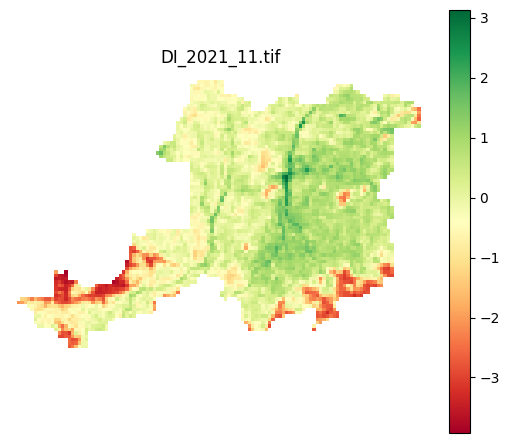

In [ ]:
++import rasterio
import matplotlib.pyplot as plt
import numpy as np
import glob
import os

BASE_PATH = "/content/drive/MyDrive/mini_project_1"

# Get yearly DI files
files = sorted(glob.glob(f"{BASE_PATH}/DI_2021_11.tif"))

print("Found yearly maps:", len(files))

n = len(files)
cols = 3
rows = (n + cols - 1) // cols

plt.figure(figsize=(15, 5 * rows))

for i, f in enumerate(files):

    with rasterio.open(f) as src:
        img = src.read(1).astype("float32")

    # Handle nodata
    img[img == -9999] = np.nan

    # Plot
    plt.subplot(rows, cols, i + 1)

    im = plt.imshow(img, cmap='RdYlGn')  # green = wet, red = drought
    plt.title(os.path.basename(f), fontsize=12)
    plt.axis('off')

    plt.colorbar(im, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
import glob
import os
import numpy as np
import pandas as pd
import rasterio

BASE_PATH = "/content/drive/MyDrive/mini_project_1"

all_files = glob.glob(f"{BASE_PATH}/DI_*.tif")

di_files = []

for f in all_files:
    name = os.path.basename(f)
    parts = name.replace('DI_', '').replace('.tif', '').split('_')

    # Only keep DI_YYYY_MM
    if len(parts) == 2 and parts[0].isdigit() and parts[1].isdigit():
        di_files.append(f)

di_files = sorted(di_files)

print("Total monthly DI files found:", len(di_files))

rows = []

for p in di_files:

    filename = os.path.basename(p)
    key = filename.replace('DI_', '').replace('.tif', '')

    year, month = key.split('_')

    with rasterio.open(p) as r:
        arr = r.read(1).astype('float32')
        arr[arr == -9999] = np.nan

        mean_di = np.nanmean(arr) if np.any(~np.isnan(arr)) else np.nan

    rows.append({
        'year': int(year),
        'month': int(month),
        'key': key,
        'mean_DI': float(mean_di)
    })

df_di = pd.DataFrame(rows)
df_di = df_di.sort_values(['year', 'month']).reset_index(drop=True)

out_path = f"{BASE_PATH}/DI_timeseries.csv"
df_di.to_csv(out_path, index=False)

print("Saved DI time series at:", out_path)
print(df_di.head())
print("Total months processed:", len(df_di))

Total monthly DI files found: 65
Saved DI time series at: /content/drive/MyDrive/mini_project_1/DI_timeseries.csv
   year  month      key  mean_DI
0  2017      1  2017_01      NaN
1  2017      2  2017_02      NaN
2  2017      3  2017_03      NaN
3  2017      4  2017_04      NaN
4  2017      5  2017_05      NaN
Total months processed: 65
